Generating animation... this might take a moment.


KeyboardInterrupt: 

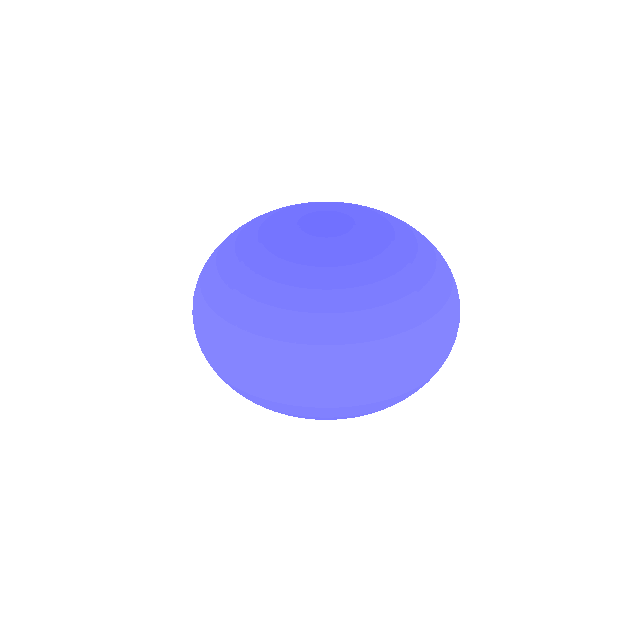

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D

# --- 1. Setup the Figure ---
fig = plt.figure(figsize=(8, 8), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# --- 2. Create the Spherical Grid ---
theta = np.linspace(0, np.pi, 60)
phi = np.linspace(0, 2 * np.pi, 60)
theta, phi = np.meshgrid(theta, phi)

# The unperturbed radius of the black hole (Event Horizon)
R0 = 1.0 

# The l=2, m=0 Spherical Harmonic shape (Quadrupole)
# Formula: Y_20 proportional to (3*cos^2(theta) - 1)
Y20 = 0.5 * (3 * np.cos(theta)**2 - 1)

# --- 3. Quasinormal Mode Physics (The Ringdown) ---
omega = 2.5   # Oscillation frequency (the "pitch" of the ring)
gamma = 0.3  # Damping factor (how fast the energy radiates away)
A0 = 0.4      # Initial strength of the perturbation
norm = mcolors.Normalize(vmin=R0 - A0*0.6, vmax=R0 + A0)

# --- 4. The Animation Function ---
def update(frame):
    ax.clear()
    
    # Time evolves with the frame count
    t = frame * 0.1
    
    # The Master Function amplitude: Decaying oscillation
    # A(t) = A_0 * e^(-gamma * t) * cos(omega * t)
    A_t = A0 * np.exp(-gamma * t) * np.cos(omega * t)
    
    # Apply the perturbation to the radius
    R = R0 + A_t * Y20
    
    # Convert spherical coordinates to Cartesian for 3D plotting
    X = R * np.sin(theta) * np.cos(phi)
    Y = R * np.sin(theta) * np.sin(phi)
    Z = R * np.cos(theta)
    
    # Plot the deformed surface
    # We color it based on the radius (R) to highlight the stretching and squeezing
    surf = ax.plot_surface(X, Y, Z, facecolors=plt.cm.seismic(norm(R)), 
                        rstride=1, cstride=1, antialiased=False, shade=False)
    
    # Lock the camera and axes so the black hole doesn't jump around
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_zlim([-1.5, 1.5])
    ax.set_axis_off()  # Hide the grid to make it look like empty space
    
    # Add a dynamic title
    # ax.text2D(0.5, 1, "Polar Perturbation", 
    #         transform=ax.transAxes, color='black', ha='center', fontsize=20)

# --- 5. Generate and Save the GIF ---
# Create 100 frames to show the initial impact and the fade to silence
print("Generating animation... this might take a moment.")
ani = FuncAnimation(fig, update, frames=200, interval=50)

# Save the animation as a GIF
gif_filename = "polar.gif"
ani.save(gif_filename, writer=PillowWriter(fps=20))
print(f"Done! Saved as {gif_filename}")

# Uncomment the line below if you want to view it in an interactive window instead of just saving
# plt.show()

Generating Axial animation...
Done! Saved as axial.gif


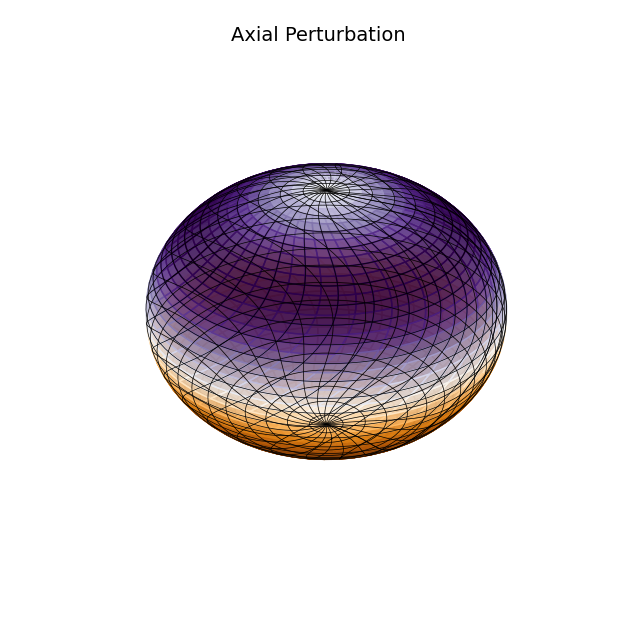

In [ ]:
# --- 1. Setup Figure (White Background) ---
fig = plt.figure(figsize=(8, 8), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# --- 2. Create Grid ---
# Use fewer points so wireframe is visible
theta_res, phi_res = 100, 100
theta_1d = np.linspace(0, np.pi, theta_res)
phi_1d = np.linspace(0, 2 * np.pi, phi_res)
theta, phi_orig = np.meshgrid(theta_1d, phi_1d)

R = 1.0 # Radius stays constant!

# --- 3. Physics: The Twist Shape ---
# For l=2 axial, the angular displacement behaves roughly like sin(2*theta).
# Max twist at 45 degrees north/south, zero twist at equator and poles.
twist_shape = np.sin(2 * theta) 

omega = 2.5   
gamma = 0.15  
A0_twist = 0.5 # Maximum angular displacement amplitude in radians

# Normalize colors based on max twist
norm_twist = mcolors.Normalize(vmin=-A0_twist, vmax=A0_twist)

# --- 4. Animation Function ---
def update(frame):
    ax.clear()
    t = frame * 0.1
    
    # Damped oscillation of the twist amplitude
    A_t = A0_twist * np.exp(-gamma * t) * np.cos(omega * t)
    
    # Apply twist to the phi coordinate
    phi_new = phi_orig + A_t * twist_shape
    
    # Spherical to Cartesian using NEW phi
    X = R * np.sin(theta) * np.cos(phi_new)
    Y = R * np.sin(theta) * np.sin(phi_new)
    Z = R * np.cos(theta)
    
    # Calculate displacement for coloring
    displacement = phi_new - phi_orig

    # Plot surface, colored by displacement amount
    # Using 'PuOr' (Purple-Orange) colormap for a distinct look from the polar one
    surf = ax.plot_surface(X, Y, Z, facecolors=plt.cm.seismic(norm_twist(displacement)), 
                        rstride=2, cstride=2, shade=False, alpha=0.8)
    
    # Add a black wireframe to make the twisting grid obvious
    ax.plot_wireframe(X, Y, Z, color='black', linewidth=0.5, rstride=4, cstride=4)
    
    # Setup axes
    ax.set_xlim([-1.1, 1.1]); ax.set_ylim([-1.1, 1.1]); ax.set_zlim([-1.1, 1.1])
    ax.set_axis_off()
    
    # Title
    # ax.text2D(0.5, 0.95, f"Axial Perturbation", 
    #         transform=ax.transAxes, color='black', ha='center', fontsize=14)

# --- 5. Generate and Save ---
print("Generating Axial animation...")
ani = FuncAnimation(fig, update, frames=200, interval=50)
gif_filename = "axial.gif"
ani.save(gif_filename, writer=PillowWriter(fps=20))
print(f"Done! Saved as {gif_filename}")

Generating comparison GIF...
Done!


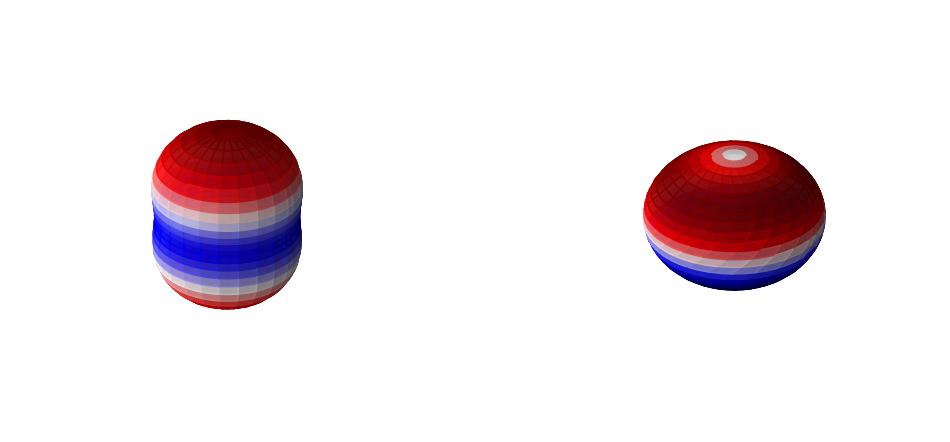

In [ ]:
# --- 1. Global Setup ---
fig = plt.figure(figsize=(12, 6), facecolor='black')
ax1 = fig.add_subplot(121, projection='3d') # Polar
ax2 = fig.add_subplot(122, projection='3d') # Axial

for ax in [ax1, ax2]:
    ax.set_facecolor('black')
    ax.xaxis.set_pane_color((1,1,1,0)); ax.yaxis.set_pane_color((1,1,1,0)); ax.zaxis.set_pane_color((1,1,1,0))

# --- 2. Grid & Physics Setup ---
res = 50
theta = np.linspace(0, np.pi, res)
phi = np.linspace(0, 2 * np.pi, res)
theta, phi_orig = np.meshgrid(theta, phi)

R0 = 1.0
A0 = 0.4
omega, gamma = 2.5, 0.12

# Common normalizer: 0 displacement = White, Max = Red, Min = Blue
norm = mcolors.TwoSlopeNorm(vmin=-A0, vcenter=0, vmax=A0)

# --- 3. Update Function ---
def update(frame):
    ax1.clear(); ax2.clear()
    t = frame * 0.1
    A_t = A0 * np.exp(-gamma * t) * np.cos(omega * t)
    
    # --- POLAR (Left) ---
    Y20 = 0.5 * (3 * np.cos(theta)**2 - 1)
    R_polar = R0 + A_t * Y20
    X_p = R_polar * np.sin(theta) * np.cos(phi_orig)
    Y_p = R_polar * np.sin(theta) * np.sin(phi_orig)
    Z_p = R_polar * np.cos(theta)
    
    ax1.plot_surface(X_p, Y_p, Z_p, facecolors=plt.cm.seismic(norm(A_t * Y20)), 
                    rstride=2, cstride=2, antialiased=True, shade=True, alpha=0.9)
    # ax1.plot_wireframe(X_p, Y_p, Z_p, color='black', linewidth=0.2, rstride=4, cstride=4)
    
    # --- AXIAL (Right) ---
    twist_shape = np.sin(2 * theta) 
    phi_axial = phi_orig + A_t * twist_shape
    X_a = R0 * np.sin(theta) * np.cos(phi_axial)
    Y_a = R0 * np.sin(theta) * np.sin(phi_axial)
    Z_a = R0 * np.cos(theta)
    
    # Color by displacement (A_t * twist_shape)
    ax2.plot_surface(X_a, Y_a, Z_a, facecolors=plt.cm.seismic(norm(A_t * twist_shape)), 
                    rstride=2, cstride=2, antialiased=True, shade=True, alpha=0.9)
    # ax2.plot_wireframe(X_a, Y_a, Z_a, color='black', linewidth=0.2, rstride=4, cstride=4)

    # --- Formatting ---
    for ax, title in zip([ax1, ax2], ["Polar (Even-Parity)", "Axial (Odd-Parity)"]):
        ax.set_xlim([-1.5, 1.5]); ax.set_ylim([-1.5, 1.5]); ax.set_zlim([-1.5, 1.5])
        ax.set_axis_off()
    #     ax.set_title(title, color='black', y=0.95)

# --- 4. Run & Save ---
print("Generating comparison GIF...")
ani = FuncAnimation(fig, update, frames=100, interval=50)
ani.save("bh_comparison.gif", writer=PillowWriter(fps=20))
print("Done!")

Generating GIF with exterior grid...


KeyboardInterrupt: 

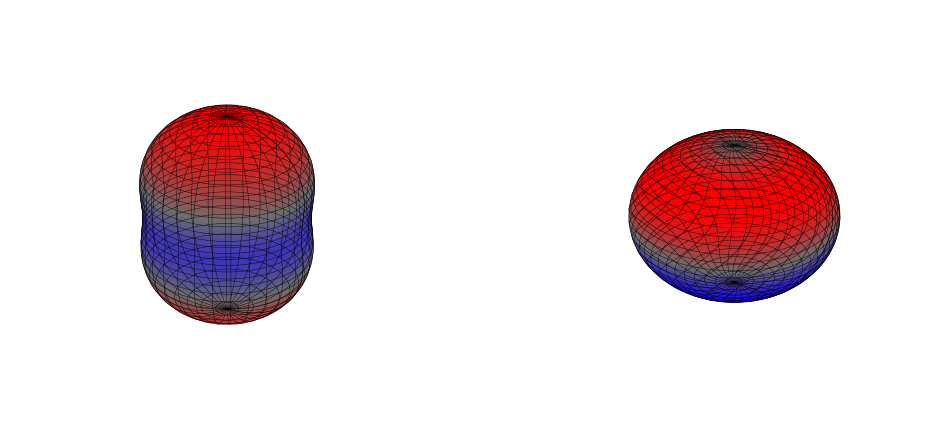

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.gridspec import GridSpec

# --- 1. Setup Figure and Layout ---
fig = plt.figure(figsize=(12, 8), facecolor='white')
gs = GridSpec(1, 2)
ax1 = fig.add_subplot(gs[0, 0], projection='3d') # Polar
ax2 = fig.add_subplot(gs[0, 1], projection='3d') # Axial

for ax in [ax1, ax2]:
    ax.set_facecolor('white')
    ax.xaxis.set_pane_color((1,1,1,0)); ax.yaxis.set_pane_color((1,1,1,0)); ax.zaxis.set_pane_color((1,1,1,0))

#fig.savefig

# --- 2. Custom "BH" Colormap (Purple -> Black -> Green) ---
colors = ["#1100FF", "#6E6E6EFF", "#FF0000"]
bh_cmap = mcolors.LinearSegmentedColormap.from_list("BH_Void", colors)

# --- 3. Physics & Grid ---
res = 120
theta = np.linspace(0, np.pi, res)
phi = np.linspace(0, 2 * np.pi, res)
theta, phi_orig = np.meshgrid(theta, phi)

R0 = 1.0
A0 = 0.4
omega, gamma = 2.5, 0.15 
total_frames = 150
time_steps = np.linspace(0, 15, total_frames)
waveform_data = A0 * np.exp(-gamma * time_steps) * np.cos(omega * time_steps)

norm = mcolors.TwoSlopeNorm(vmin=-A0, vcenter=0, vmax=A0)

# --- 4. Animation Function ---
def update(frame):
    ax1.clear(); ax2.clear()
    t = time_steps[frame]
    A_t = waveform_data[frame]
    
    # Tiny offset factor to prevent Z-fighting (Wireframe sits 1% above surface)
    grid_offset = 1.01 
    
    # --- POLAR (Left) ---
    Y20 = 0.5 * (3 * np.cos(theta)**2 - 1)
    disp_p = A_t * Y20
    R_p = R0 + disp_p
    
    # Surface Coordinates
    Xp, Yp, Zp = R_p*np.sin(theta)*np.cos(phi_orig), R_p*np.sin(theta)*np.sin(phi_orig), R_p*np.cos(theta)
    # Wireframe Coordinates (Offset)
    Xp_g, Yp_g, Zp_g = (R_p*grid_offset)*np.sin(theta)*np.cos(phi_orig), (R_p*grid_offset)*np.sin(theta)*np.sin(phi_orig), (R_p*grid_offset)*np.cos(theta)
    
    ax1.plot_surface(Xp, Yp, Zp, facecolors=bh_cmap(norm(disp_p)), rstride=2, cstride=2, antialiased=True, shade=False)
    ax1.plot_wireframe(Xp_g, Yp_g, Zp_g, color='black', linewidth=0.3, alpha=1, rstride=4, cstride=4)
    
    # --- AXIAL (Right) ---
    twist_shape = np.sin(2 * theta) 
    disp_a = A_t * twist_shape
    phi_axial = phi_orig + disp_a
    
    # Surface Coordinates
    Xa, Ya, Za = R0*np.sin(theta)*np.cos(phi_axial), R0*np.sin(theta)*np.sin(phi_axial), R0*np.cos(theta)
    # Wireframe Coordinates (Offset)
    Xa_g, Ya_g, Za_g = (R0*grid_offset)*np.sin(theta)*np.cos(phi_axial), (R0*grid_offset)*np.sin(theta)*np.sin(phi_axial), (R0*grid_offset)*np.cos(theta)
    
    ax2.plot_surface(Xa, Ya, Za, facecolors=bh_cmap(norm(disp_a)), rstride=2, cstride=2, antialiased=True, shade=False)
    ax2.plot_wireframe(Xa_g, Ya_g, Za_g, color='black', linewidth=0.3, alpha=1, rstride=4, cstride=4)

    # Final Formatting
    for ax, title in zip([ax1, ax2], ["Polar (Even)", "Axial (Odd)"]):
        ax.set_xlim([-1.3, 1.3]); ax.set_ylim([-1.3, 1.3]); ax.set_zlim([-1.3, 1.3])
        ax.set_axis_off()
        # ax.set_title(title, color='black', fontsize=12, y=0.9)

# --- 5. Export ---
print("Generating GIF with exterior grid...")
ani = FuncAnimation(fig, update, frames=total_frames, interval=50)
ani.save("Perturbation_comparison.gif", writer=PillowWriter(fps=20))
print("Done!")